# Testing of Sequentially Trained Models

**Objectives:**
1. Load the final model weights (Transformer+OC-SVM, PRAE, PNN) trained in notebook 1.
2. Evaluate on the held-out **Test Day (Day 25)**.
3. Split the trading day into meaningful time periods (1st hour, rest of morning, afternoon, American open, after-market close).
4. Classify anomalies:
    - Transformer + OC-SVM: OC-SVM decision function.
    - PNN: Spoofing gain.
    - PRAE: Rolling False Discovery Rate (RFDR) on the reconstruction error ($\mu$ is unavailable for a test set).
5. Visualize anomaly scores and detections across time periods.
6. Perform **Root Cause Analysis** -- identify features contributing most to top anomalies.

In [ ]:
import os, sys, math, logging, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import joblib

sys.path.insert(0, os.path.abspath(".."))

from detection.data import datasets, loaders, preprocessing, scalers
from detection.features import dynamics, event_flow, hawkes, imbalance, ofi, volatility
from detection.models import hybrid, pnn, prae
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Configuration

In [ ]:
DATA_DIR = os.path.join("..", "data", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

# Hyperparameters (must match training notebook)
SEQ_LENGTH = 25
BATCH_SIZE = 64
WARMUP_STEPS = 3000
WINDOW = 50

TAO_CONFIGS = [
    {"name": "Weighted_Imbalance_decreasing",  "weights": [0.1, 0.1, 0.2, 0.2, 0.4], "levels": 5},
    {"name": "Weighted_Imbalance_increasing",  "weights": [0.4, 0.2, 0.2, 0.1, 0.1], "levels": 5},
    {"name": "Weighted_Imbalance_constant",    "weights": [0.2, 0.2, 0.2, 0.2, 0.2], "levels": 5},
]

# RFDR threshold params (used only for PRAE)
RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

# Spoofing gain params (used only for PNN)
SPOOF_Q = 4500         # spoof order size
SPOOF_q = 100          # genuine order size
SPOOF_DELTA_A = 0.0    # ask order at best ask
SPOOF_DELTA_B = 0.01   # spoof bid close to best bid
SPOOF_FEES = {"maker": 0.0, "taker": 0.05}

# Test files
FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv.gz")))
TEST_FILES = [FILES[3], FILES[4]]
print(f"Available files: {len(FILES)}")
for i, f in enumerate(TEST_FILES):
    print(f"Test file {i+1}: {os.path.basename(f)}")

# Time-of-day periods for Euronext Paris (in hours since midnight, CET)
PERIODS = {
    "1st_hour":       (9.0,  10.0),
    "rest_of_morning":(10.0, 12.0),
    "afternoon":      (12.0, 15.5),
    "american_open":  (15.5, 17.5),
    "aftermarket":    (17.5, 24.0),
}
print("Periods:", {k: f"{v[0]:.1f}h-{v[1]:.1f}h" for k, v in PERIODS.items()})

Available files: 25
  Test file 1: 2015-01-07-TOTF.PA-book.csv.gz
  Test file 2: 2015-01-08-TOTF.PA-book.csv.gz
Periods: {'1st_hour': '9.0h-10.0h', 'rest_of_morning': '10.0h-12.0h', 'afternoon': '12.0h-15.5h', 'american_open': '15.5h-17.5h', 'aftermarket': '17.5h-24.0h'}


## Helper Functions

In [ ]:
def load_and_clean(filepath):
    """Load a single day CSV, clean, and filter market hours (including aftermarket)."""
    df = datasets.get_lob(filepath)
    df = preprocessing.clean_lob(df)
    df = preprocessing.filter_market_hours(df, time_col="xltime", market_open_hour=9.0, market_close_hour=24.0)
    return df


def engineer_features(df):
    """Compute the full feature set from raw LOB data."""
    features = pd.DataFrame(index=df.index)
    df = df.copy()
    df = imbalance.compute_imbalance(df)
    features["L1_Imbalance"] = df["L1_Imbalance"]
    features["L5_Imbalance"] = df["L5_Imbalance"]
    features = dynamics.compute_dynamics(df, features, window=WINDOW)
    features = dynamics.compute_elasticity(df, features)
    features = volatility.compute_volatility(df, features, window=WINDOW)
    for tc in TAO_CONFIGS:
        features[tc["name"]] = imbalance.compute_weighted_imbalance(df, weights=tc["weights"], levels=tc.get("levels", 5))
    features = event_flow.compute_event_flow(df, features)
    features = hawkes.compute_hawkes(df, features)
    features = ofi.compute_ofi(df, features)
    features.replace([np.inf, -np.inf], np.nan, inplace=True)
    features = features.fillna(0)
    if len(features) > WARMUP_STEPS:
        features = features.iloc[WARMUP_STEPS:].reset_index(drop=True)
    lower = features.quantile(0.001)
    upper = features.quantile(0.999)
    features = features.clip(lower=lower, upper=upper, axis=1)
    std_devs = features.std()
    drop_cols = std_devs[std_devs < 1e-9].index.tolist()
    if drop_cols:
        features = features.drop(columns=drop_cols)
    return features


def get_time_frac(df):
    """Return the fractional time-of-day from xltime."""
    base_date = np.floor(df["xltime"].values)
    return df["xltime"].values - base_date


def assign_period(time_frac_arr):
    """Assign each row to a named trading period."""
    labels = np.full(len(time_frac_arr), "unknown", dtype=object)
    for name, (open_h, close_h) in PERIODS.items():
        mask = (time_frac_arr >= open_h / 24.0) & (time_frac_arr < close_h / 24.0)
        labels[mask] = name
    return labels


def build_model(model_type, num_features, weights_path):
    """Reconstruct a model from saved weights."""
    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
        )
        transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        transformer.eval().to(DEVICE)
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        if os.path.exists(ocsvm_path):
            ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False)
        else:
            logger.warning("Nyström OC-SVM not found; scoring via reconstruction error fallback.")
            ocsvm = None
        return transformer, ocsvm
    elif model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = pnn.PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        model.eval()
        return model, None
    elif model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
        )
        model = prae.PRAE(backbone_model=backbone, num_train_samples=1, lambda_reg=1.0, sigma=0.5).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        return model, None
    else:
        raise ValueError(f"Unknown model type: {model_type}")

## Load Feature Names

In [4]:
# Read feature names from saved file (to ensure column order matches training)
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as f:
            feature_names_map[mt] = [line.strip() for line in f if line.strip()]
    else:
        # Load first test file to get default feature names
        _df_tmp = load_and_clean(TEST_FILES[0])
        _feat_tmp = engineer_features(_df_tmp)
        feature_names_map[mt] = _feat_tmp.columns.tolist()
        del _df_tmp, _feat_tmp

print(f"Feature names loaded for {len(feature_names_map)} models")
for mt, fnames in feature_names_map.items():
    print(f"  {mt}: {len(fnames)} features")

Feature names loaded for 3 models
  transformer_ocsvm: 88 features
  pnn: 88 features
  prae: 88 features


## Score Test Days with Each Model

For each test file, load the raw LOB data, compute features, and score with all three models. Results are concatenated across files.

- **Transformer + OC-SVM** — OC-SVM decision function (distance to hyperplane); anomaly if outside the boundary.
- **PNN** — Spoofing gain: expected cost reduction from a hypothetical spoof order; anomaly if gain > 0.
- **PRAE** — Rolling False Discovery Rate (RFDR) on reconstruction error ($\mu$ unavailable at test time).

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# ── Pre-load models and scalers (once for all test files) ────────────────
loaded_models = {}
loaded_scalers = {}

for model_type in MODEL_TYPES:
    feat_names = feature_names_map[model_type]
    num_features = len(feat_names)
    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
    model, ocsvm = build_model(model_type, num_features, weights_path)
    loaded_models[model_type] = (model, ocsvm)

    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    loaded_scalers[model_type] = joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
    logger.info("Loaded model & scaler for %s (%d features)", model_type, num_features)

# Score each test file and accumulate results
all_scores = {mt: [] for mt in MODEL_TYPES}
all_preds = {mt: [] for mt in MODEL_TYPES}
all_thresholds = {mt: 0.0 for mt in MODEL_TYPES}
all_period_labels_seq = []
all_feat_values_seq = []
day_boundaries = [0]   # cumulative sample offsets per day
day_names = []

for file_idx, test_file in enumerate(TEST_FILES):
    day_name = os.path.basename(test_file)
    day_names.append(day_name)
    logger.info("=" * 70)
    logger.info("Test file %d/%d: %s", file_idx + 1, len(TEST_FILES), day_name)

    # Load & feature-engineer this day
    df_day = load_and_clean(test_file)
    features_day = engineer_features(df_day)

    # Period labels (aligned to features_day)
    time_frac_day = get_time_frac(df_day)[:len(features_day)]
    period_labels_day = assign_period(time_frac_day)

    # Spread from raw LOB data (needed for PNN)
    spread_raw_day = (df_day["ask-price-1"] - df_day["bid-price-1"]).values

    # Number of sequences for this day
    n_seq_day = len(features_day) - SEQ_LENGTH

    # Period labels aligned to sequences
    period_labels_day_seq = period_labels_day[SEQ_LENGTH: SEQ_LENGTH + n_seq_day]
    all_period_labels_seq.append(period_labels_day_seq)

    # Feature values aligned to sequences
    feat_values_day_seq = features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq_day].reset_index(drop=True)
    all_feat_values_seq.append(feat_values_day_seq)

    logger.info("Day rows (after warmup): %d → %d sequences", len(features_day), n_seq_day)

    # Score with each model
    for model_type in MODEL_TYPES:
        feat_names = feature_names_map[model_type]
        scaler = loaded_scalers[model_type]
        model, ocsvm = loaded_models[model_type]

        # Align features to training column order
        feat_df = features_day.copy()
        for col in feat_names:
            if col not in feat_df.columns:
                feat_df[col] = 0.0
        feat_df = feat_df[feat_names]

        # Scale
        scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)

        # Create sequences
        sequences = loaders.create_sequences(scaled, SEQ_LENGTH)
        num_features = len(feat_names)

        # ────────────────────────────────────────────────────────────
        # Transformer + Nyström OC-SVM
        # ────────────────────────────────────────────────────────────
        if model_type == "transformer_ocsvm":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            ds = TensorDataset(x_tensor, x_tensor)
            loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
            if ocsvm is not None:
                detector = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                detector.transformer = model
                detector.ocsvm = ocsvm
                scores = detector.predict(loader)
            else:
                scores_list = []
                model.eval()
                with torch.no_grad():
                    for batch in loader:
                        x = batch[0].to(DEVICE)
                        rec = model(x)
                        err = torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                        scores_list.append(err)
                scores = np.concatenate(scores_list)
            del x_tensor, ds, loader
            preds = (scores > 0).astype(int)
            threshold_val = 0.0

        # ────────────────────────────────────────────────────────────
        # PNN: Spoofing gain  (vectorised – no Python loop)
        # ────────────────────────────────────────────────────────────
        elif model_type == "pnn":
            target_col = "log_return"
            target_idx = feat_names.index(target_col) if target_col in feat_names else 0

            # Collect PNN distribution parameters batch-by-batch
            all_mu, all_sigma, all_alpha = [], [], []
            n_seqs = len(sequences)
            model.eval()
            with torch.no_grad():
                for start in range(0, n_seqs, BATCH_SIZE):
                    end = min(start + BATCH_SIZE, n_seqs)
                    x_batch = torch.tensor(
                        np.ascontiguousarray(sequences[start:end]),
                        dtype=torch.float32,
                    ).reshape(end - start, -1).to(DEVICE)
                    mu, sigma, alpha = model(x_batch)
                    all_mu.append(mu.cpu().numpy().flatten())
                    all_sigma.append(sigma.cpu().numpy().flatten())
                    all_alpha.append(alpha.cpu().numpy().flatten())

            mu_arr = np.concatenate(all_mu)
            sigma_arr = np.concatenate(all_sigma)
            alpha_arr = np.concatenate(all_alpha)

            spread_seq = spread_raw_day[WARMUP_STEPS + SEQ_LENGTH: WARMUP_STEPS + SEQ_LENGTH + len(mu_arr)]
            if len(spread_seq) < len(mu_arr):
                spread_seq = np.pad(spread_seq, (0, len(mu_arr) - len(spread_seq)), mode="edge")
            spread_seq = np.abs(spread_seq)
            spread_seq = np.where(spread_seq > 0, spread_seq, 1e-4)

            # Vectorised: computes all samples in two bulk CDF calls
            spoofing_gains = compute_spoofing_gains_batch(
                mu_arr, sigma_arr, alpha_arr, spread_seq,
                delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
                Q=SPOOF_Q, q=SPOOF_q,
                fees=SPOOF_FEES, side="ask",
            )

            scores = spoofing_gains
            preds = (scores > 0).astype(int)
            threshold_val = 0.0

        # ────────────────────────────────────────────────────────────
        # PRAE: RFDR on reconstruction error
        # ────────────────────────────────────────────────────────────
        elif model_type == "prae":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            ds = TensorDataset(x_tensor, x_tensor)
            loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
            scores_list = []
            model.eval()
            with torch.no_grad():
                for batch in loader:
                    x = batch[0].to(DEVICE)
                    rec, _ = model(x, training=False)
                    err = torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim()))).cpu().numpy()
                    scores_list.append(err)
            scores = np.concatenate(scores_list)
            del x_tensor, ds, loader

            rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
            preds = np.zeros(len(scores), dtype=int)
            threshold_val = 0.0
            for i, s in enumerate(scores):
                is_anom, threshold_val = rfdr.process_new_score(float(s))
                preds[i] = int(is_anom)

        all_scores[model_type].append(scores)
        all_preds[model_type].append(preds)
        all_thresholds[model_type] = threshold_val

        logger.info("  %s: %d anomalies / %d samples (%.2f%%)",
                    model_type, preds.sum(), len(preds), 100 * preds.mean())

    day_boundaries.append(day_boundaries[-1] + n_seq_day)

# Concatenate across all test files
for mt in MODEL_TYPES:
    all_scores[mt] = np.concatenate(all_scores[mt])
    all_preds[mt] = np.concatenate(all_preds[mt])

period_labels_seq = np.concatenate(all_period_labels_seq)
feat_values_seq = pd.concat(all_feat_values_seq, ignore_index=True)

total_samples = len(next(iter(all_scores.values())))
print(f"\nScoring complete: {total_samples} total samples across {len(TEST_FILES)} test file(s).")
for mt in MODEL_TYPES:
    n_anom = all_preds[mt].sum()
    print(f"  {mt}: {n_anom} anomalies ({100*n_anom/total_samples:.2f}%)")

2026-02-25 17:21:11,309 | INFO | Loaded model & scaler for transformer_ocsvm (88 features)
2026-02-25 17:21:11,309 | INFO | Loaded model & scaler for pnn (88 features)
2026-02-25 17:21:11,389 | INFO | Loaded model & scaler for prae (88 features)
2026-02-25 17:21:11,389 | INFO | ======================================================================
2026-02-25 17:21:11,389 | INFO | Test file 1/2: 2015-01-07-TOTF.PA-book.csv.gz
2026-02-25 17:21:15,925 | INFO | Dropped artifact columns: ['Unnamed: 1']
2026-02-25 17:21:16,524 | INFO | Market-hours filter [9.0:00 -- 24.0:00]: kept 994837 / 1124864 rows (dropped 130027 pre/post-market).
2026-02-25 17:21:29,209 | INFO |   Day rows (after warmup): 991837 → 991812 sequences
2026-02-25 17:22:56,921 | INFO |   transformer_ocsvm: 8832 anomalies / 991812 samples (0.89%)
2026-02-25 17:42:02,781 | INFO |   pnn: 4 anomalies / 991812 samples (0.00%)
2026-02-25 17:47:48,643 | INFO |   prae: 24982 anomalies / 991812 samples (2.52%)
2026-02-25 17:47:48,643


Scoring complete: 1963144 total samples across 2 test file(s).
  transformer_ocsvm: 17022 anomalies (0.87%)
  pnn: 87 anomalies (0.00%)
  prae: 53844 anomalies (2.74%)


In [ ]:
# ── Diagnostic: why does OC-SVM find 0 anomalies? ──────────────────────────
# Inspect the internal state of the loaded Nyström OC-SVM (using the first test file).

weights_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_weights.pth")
feat_names  = feature_names_map["transformer_ocsvm"]
num_features = len(feat_names)

transformer = BottleneckTransformer(
    num_features=num_features, model_dim=64, num_heads=4,
    num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
)
transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
transformer.eval().to(DEVICE)

ocsvm_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_detector.pth")
ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False)

print("=== Nyström OC-SVM internal state ===")
print(f"  gamma  (γ)   : {ocsvm._gamma}")
print(f"  rho    (ρ)   : {ocsvm._rho.item():.6f}")
print(f"  ||w||         : {ocsvm._w.norm().item():.6f}")
print(f"  n_landmarks   : {ocsvm._landmarks.shape}")
print()

# Compute a small batch of latent representations (first test file)
_diag_df = load_and_clean(TEST_FILES[0])
_diag_features = engineer_features(_diag_df)
feat_df = _diag_features.copy()
for col in feat_names:
    if col not in feat_df.columns:
        feat_df[col] = 0.0
feat_df = feat_df[feat_names]
scaler_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_scaler.pkl")
_scaler = joblib.load(scaler_path)
scaled = _scaler.transform(feat_df.values[:5000].astype(np.float32)).astype(np.float32)
seqs = loaders.create_sequences(scaled, SEQ_LENGTH)
x_t = torch.tensor(seqs[:512], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    z = transformer.get_representation(x_t)

print("=== Latent space statistics (512 samples) ===")
print(f"  shape        : {z.shape}")
print(f"  mean         : {z.mean().item():.6f}")
print(f"  std          : {z.std().item():.6f}")
print(f"  var (overall): {z.var().item():.6f}")
print()

# ── Kernel sanity check ──
d = z.shape[1]
var_z = z.var().item()
expected_dist2 = 2 * d * var_z
gamma = ocsvm._gamma
typical_kernel = np.exp(-gamma * expected_dist2)
print("=== Kernel sanity check ===")
print(f"  d (latent dim)           : {d}")
print(f"  Var(z)                   : {var_z:.6f}")
print(f"  gamma                    : {gamma:.8f}")
print(f"  Expected ||x-y||²        : {expected_dist2:.2f}")
print(f"  Typical K(x,y)           : {typical_kernel:.2e}")
print(f"  → If K(x,y) ≈ 0 for all pairs, Nyström features collapse to ~0")
print(f"    and decision_function ≈ -ρ = {-ocsvm._rho.item():.6f} for ALL samples.")
print()

# ── Actual decision function distribution ──
scores_ocsvm = all_scores.get("transformer_ocsvm")
if scores_ocsvm is not None:
    df_vals = -scores_ocsvm
    print("=== Decision function distribution (positive=inlier) ===")
    print(f"  min   : {df_vals.min():.8f}")
    print(f"  max   : {df_vals.max():.8f}")
    print(f"  mean  : {df_vals.mean():.8f}")
    print(f"  std   : {df_vals.std():.8f}")
    print(f"  All positive (inlier)? {(df_vals > 0).all()}")
    print(f"  Range is tiny? {df_vals.max() - df_vals.min():.2e}")
del _diag_df, _diag_features

=== Nyström OC-SVM internal state ===
  gamma  (γ)   : 4.699400376704668e-05
  rho    (ρ)   : -0.097962
  ||w||         : 0.122221
  n_landmarks   : torch.Size([300, 128])



2026-02-25 18:12:34,538 | INFO | Dropped artifact columns: ['Unnamed: 1']
2026-02-25 18:12:35,129 | INFO | Market-hours filter [9.0:00 -- 24.0:00]: kept 994837 / 1124864 rows (dropped 130027 pre/post-market).


=== Latent space statistics (512 samples) ===
  shape        : torch.Size([512, 128])
  mean         : 0.250570
  std          : 9.929746
  var (overall): 98.599846

=== Kernel sanity check ===
  d (latent dim)           : 128
  Var(z)                   : 98.599846
  gamma                    : 0.00004699
  Expected ||x-y||²        : 25241.56
  Typical K(x,y)           : 3.05e-01
  → If K(x,y) ≈ 0 for all pairs, Nyström features collapse to ~0
    and decision_function ≈ -ρ = 0.097962 for ALL samples.

=== Decision function distribution (positive=inlier) ===
  min   : -0.01300071
  max   : 0.07466426
  mean  : 0.02373075
  std   : 0.01098183
  All positive (inlier)? False
  Range is tiny? 8.77e-02


## Anomaly Rates by Time Period

Anomaly rate (%) by period and model (cumulated over 2 test files):


Model,pnn,prae,transformer_ocsvm
Period,,,
1st_hour,0.00,2.29,0.87
rest_of_morning,0.00,2.37,1.14
afternoon,0.00,2.74,0.87
american_open,0.01,3.34,0.58
aftermarket,NaN,NaN,NaN


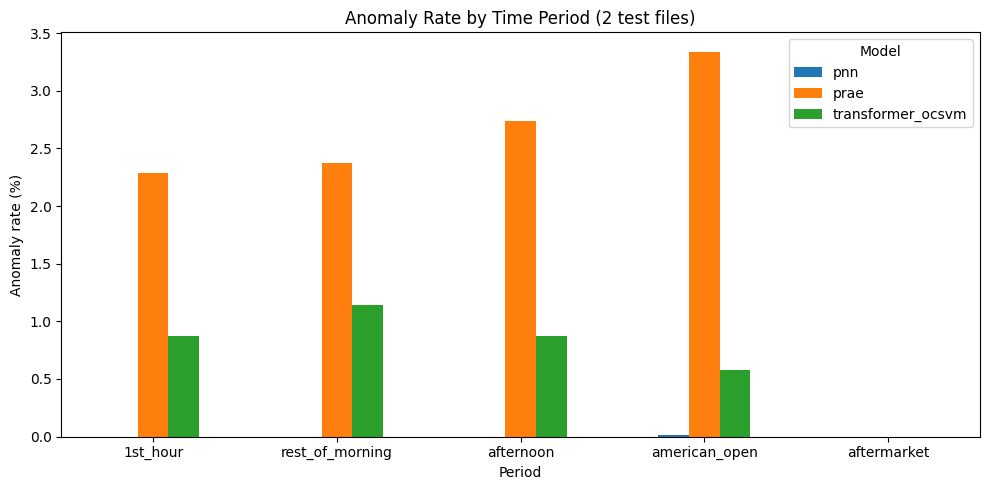

In [7]:
# period_labels_seq is already computed in the scoring cell

rows = []
for mt in MODEL_TYPES:
    preds = all_preds[mt]
    n = min(len(preds), len(period_labels_seq))
    for period_name in PERIODS:
        mask = period_labels_seq[:n] == period_name
        total = mask.sum()
        if total == 0:
            continue
        n_anom = preds[:n][mask].sum()
        rows.append({
            "Model": mt,
            "Period": period_name,
            "Total": int(total),
            "Anomalies": int(n_anom),
            "Rate (%)": round(100 * n_anom / total, 2),
        })

period_df = pd.DataFrame(rows)
pivot = period_df.pivot_table(index="Period", columns="Model", values="Rate (%)", aggfunc="first")
pivot = pivot.reindex([p for p in PERIODS])

n_days = len(TEST_FILES)
print(f"Anomaly rate (%) by period and model (cumulated over {n_days} test file{'s' if n_days > 1 else ''}):")
display(pivot)

# Bar chart
ax = pivot.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylabel("Anomaly rate (%)")
ax.set_title(f"Anomaly Rate by Time Period ({n_days} test file{'s' if n_days > 1 else ''})")
ax.legend(title="Model")
plt.tight_layout()
plt.show()

## Anomaly Score Visualization

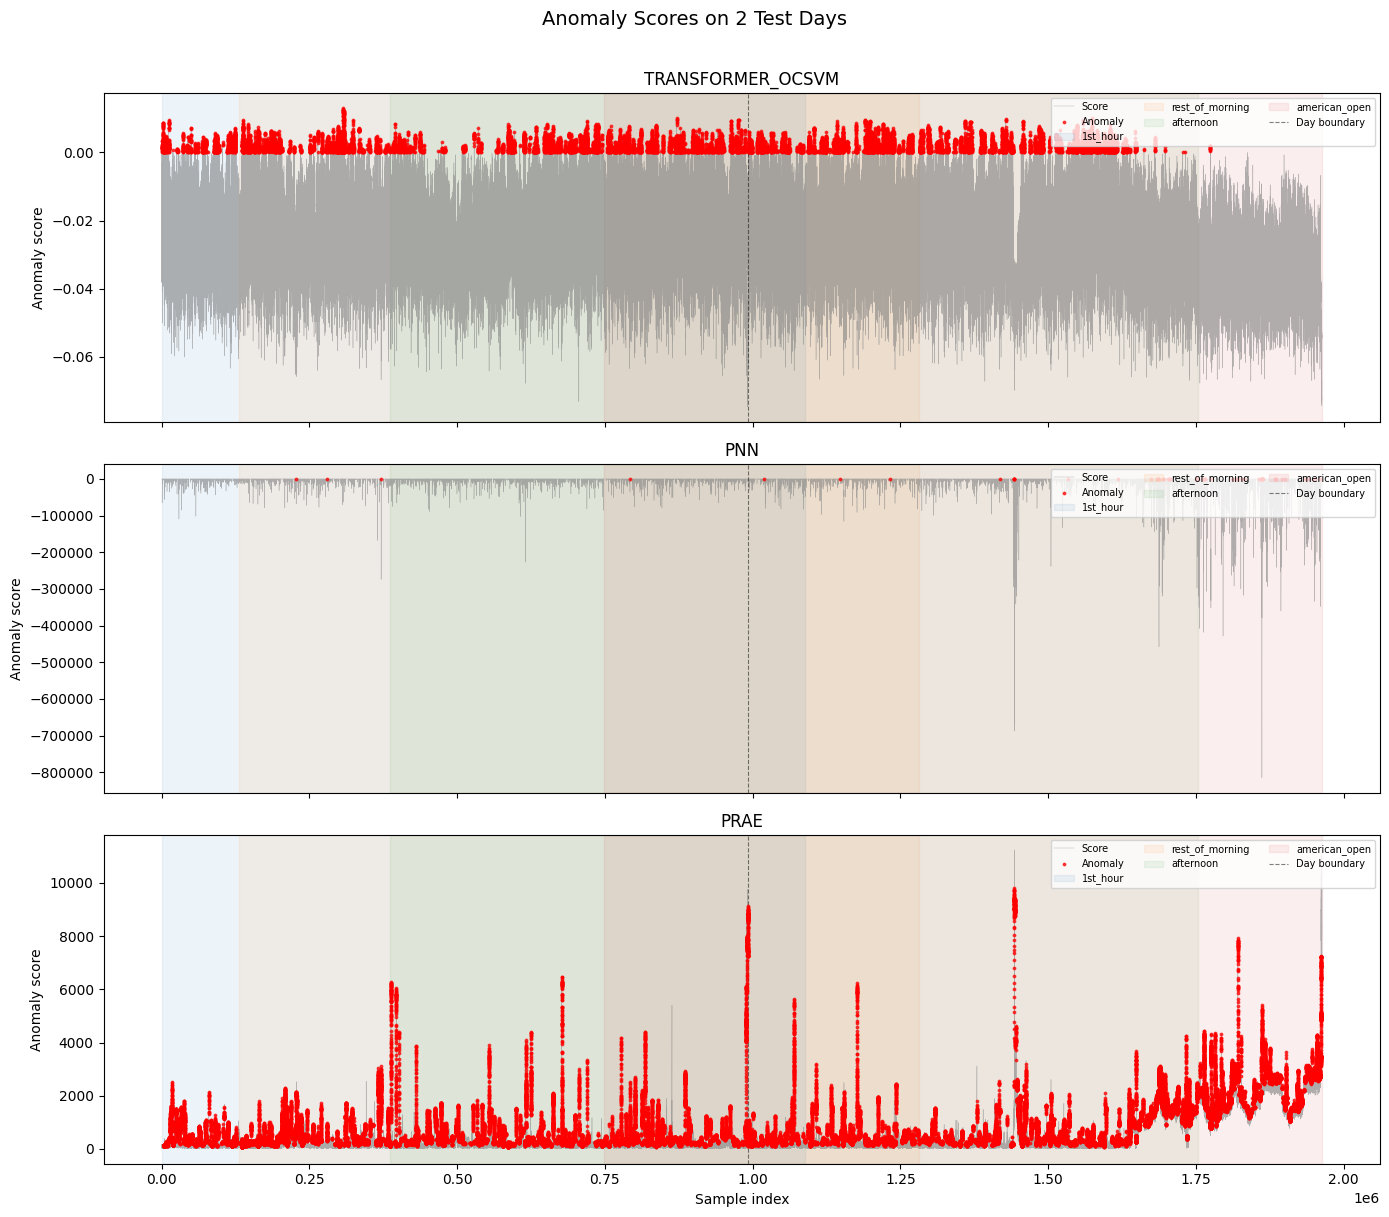

In [8]:
fig, axes = plt.subplots(len(MODEL_TYPES), 1, figsize=(14, 4 * len(MODEL_TYPES)), sharex=True)
if len(MODEL_TYPES) == 1:
    axes = [axes]

colors = {"1st_hour": "#1f77b4", "rest_of_morning": "#ff7f0e",
          "afternoon": "#2ca02c", "american_open": "#d62728",
          "aftermarket": "#9467bd"}

for ax, mt in zip(axes, MODEL_TYPES):
    scores = all_scores[mt]
    preds = all_preds[mt]
    n = min(len(scores), len(period_labels_seq))

    ax.plot(range(n), scores[:n], linewidth=0.3, alpha=0.6, color="grey", label="Score")
    # Highlight anomalies
    anom_idx = np.where(preds[:n] == 1)[0]
    if len(anom_idx) > 0:
        ax.scatter(anom_idx, scores[anom_idx], s=3, c="red", zorder=3, label="Anomaly", alpha=0.7)

    # Shade periods
    for period_name, color in colors.items():
        mask = period_labels_seq[:n] == period_name
        if mask.any():
            indices = np.where(mask)[0]
            ax.axvspan(indices[0], indices[-1], alpha=0.08, color=color, label=period_name)

    # Day boundaries (vertical lines)
    for b_idx, boundary in enumerate(day_boundaries[1:-1], start=1):
        if boundary < n:
            ax.axvline(boundary, color="black", linestyle="--", linewidth=0.8,
                       alpha=0.5, label="Day boundary" if b_idx == 1 else None)

    ax.set_ylabel("Anomaly score")
    ax.set_title(f"{mt.upper()}")
    ax.legend(loc="upper right", fontsize=7, ncol=3)

axes[-1].set_xlabel("Sample index")
n_days = len(TEST_FILES)
plt.suptitle(f"Anomaly Scores on {n_days} Test Day{'s' if n_days > 1 else ''}", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Root Cause Analysis

For each model, examine the **top anomaly** and the **top 10% anomalies** to identify which features contribute the most. We compare the feature values at anomalous time steps against the non-anomalous baseline (mean + std).

In [9]:
# feat_values_seq and period_labels_seq are already computed in the scoring cell
feat_cols = feat_values_seq.columns.tolist()

for mt in MODEL_TYPES:
    scores = all_scores[mt]
    preds = all_preds[mt]
    n = min(len(scores), len(feat_values_seq))

    print(f"\n{'='*70}")
    print(f"ROOT CAUSE ANALYSIS: {mt.upper()}")
    print(f"{'='*70}")

    # --- Top anomaly ---
    top_idx = np.argmax(scores[:n])
    top_score = scores[top_idx]
    top_period = period_labels_seq[top_idx] if top_idx < len(period_labels_seq) else "?"
    # Identify which test day the top anomaly belongs to
    top_day = next((d for d, (lo, hi) in enumerate(zip(day_boundaries[:-1], day_boundaries[1:])) if lo <= top_idx < hi), 0)
    print(f"\n  Top anomaly at index {top_idx} (day: {day_names[top_day]}, period: {top_period}, score: {top_score:.4f})")

    # Z-score of top anomaly features vs normal baseline
    normal_mask = preds[:n] == 0
    if normal_mask.sum() > 10:
        normal_mean = feat_values_seq.iloc[:n][normal_mask].mean()
        normal_std = feat_values_seq.iloc[:n][normal_mask].std().replace(0, 1e-10)
        top_feat = feat_values_seq.iloc[top_idx]
        z_scores = ((top_feat - normal_mean) / normal_std).abs().sort_values(ascending=False)
        print(f"\n  Top 10 features by |z-score| at the top anomaly:")
        for feat_name, z in z_scores.head(10).items():
            val = top_feat[feat_name]
            print(f"    {feat_name:45s}  z={z:7.2f}  val={val:10.4f}")

    # --- Top 10% anomalies ---
    threshold_10pct = np.percentile(scores[:n], 90)
    top10_mask = scores[:n] >= threshold_10pct
    n_top10 = top10_mask.sum()
    print(f"\n  Top 10% anomalies ({n_top10} samples, score >= {threshold_10pct:.4f}):")

    if normal_mask.sum() > 10:
        top10_feats = feat_values_seq.iloc[:n][top10_mask]
        top10_mean = top10_feats.mean()
        diff = ((top10_mean - normal_mean) / normal_std).abs().sort_values(ascending=False)
        print(f"  Top 10 features by mean |z-score| deviation:")
        for feat_name, d in diff.head(10).items():
            print(f"    {feat_name:45s}  mean_z={d:7.2f}  "
                  f"anom_mean={top10_mean[feat_name]:10.4f}  "
                  f"normal_mean={normal_mean[feat_name]:10.4f}")

    # Period breakdown for top 10%
    if len(period_labels_seq) >= n:
        top10_periods = pd.Series(period_labels_seq[:n][top10_mask]).value_counts()
        print(f"\n  Period distribution of top 10% anomalies:")
        for p, cnt in top10_periods.items():
            print(f"    {p:25s}  {cnt:5d}")

print("\nRoot cause analysis complete.")


ROOT CAUSE ANALYSIS: TRANSFORMER_OCSVM

  Top anomaly at index 306204 (day: 2015-01-07-TOTF.PA-book.csv.gz, period: rest_of_morning, score: 0.0130)

  Top 10 features by |z-score| at the top anomaly:
    order_flow_imbalance_level_4                   z=   1.91  val=  -41.1100
    Deep_order_insertion_bid                       z=   1.15  val=    0.0005
    Hawkes_M_bid_beta10                            z=   0.82  val=    0.4467
    Hawkes_M_ask_beta10                            z=   0.79  val=    0.8100
    Hawkes_M_bid_short                             z=   0.76  val=    0.0303
    SMA_trade_bid                                  z=   0.73  val=    0.0000
    Hawkes_M_ask_short                             z=   0.73  val=    0.0401
    dt                                             z=   0.70  val=    0.0010
    SMA_trade_ask                                  z=   0.70  val=    0.0000
    Hawkes_L_bid_long                              z=   0.60  val=    0.0000

  Top 10% anomalies (196315 